# Week 1 - Setup and Data Verification

Goals:
1. Verify Colab environment.
2. Download GTSRB.
3. Inspect dataset structure and annotations.
4. Visualize samples.
5. Create train/validation split.
6. Save outputs for Week 2.


In [1]:
import os
import random
import pathlib
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torchvision
from torchvision.datasets import GTSRB
from torchvision import transforms

from sklearn.model_selection import train_test_split

In [2]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.10.0+cu128
Torchvision: 0.25.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
PROJECT_ROOT = pathlib.Path("/content/traffic-sign-classification")
DATA_ROOT = PROJECT_ROOT / "data"
REPORT_ROOT = PROJECT_ROOT / "reports" / "week1"
SPLIT_ROOT = PROJECT_ROOT / "artifacts" / "splits"

for p in [PROJECT_ROOT, DATA_ROOT, REPORT_ROOT, SPLIT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data root:", DATA_ROOT)

Project root: /content/traffic-sign-classification
Data root: /content/traffic-sign-classification/data


In [4]:
print("Recommended workflow:")
print("1. Open notebook from GitHub in Colab")
print("2. Work in Colab")
print("3. Save notebook back with File > Save a copy in GitHub")
print("4. Download generated CSV/PNG files and upload them to GitHub if needed")

Recommended workflow:
1. Open notebook from GitHub in Colab
2. Work in Colab
3. Save notebook back with File > Save a copy in GitHub
4. Download generated CSV/PNG files and upload them to GitHub if needed


In [5]:
train_raw = GTSRB(root=str(DATA_ROOT), split="train", download=True)
test_raw = GTSRB(root=str(DATA_ROOT), split="test", download=True)

print("Train samples:", len(train_raw))
print("Test samples:", len(test_raw))

100%|██████████| 187M/187M [00:04<00:00, 39.4MB/s]
100%|██████████| 89.0M/89.0M [00:02<00:00, 40.7MB/s]
100%|██████████| 99.6k/99.6k [00:00<00:00, 1.47MB/s]


Train samples: 26640
Test samples: 12630


Image type: <class 'PIL.Image.Image'>
Image size: (29, 30)
Label: 0


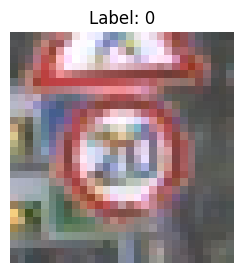

In [6]:
img, label = train_raw[0]

print("Image type:", type(img))
print("Image size:", img.size)
print("Label:", label)

plt.figure(figsize=(3, 3))
plt.imshow(img)
plt.title(f"Label: {label}")
plt.axis("off")
plt.show()

In [7]:
train_dir = DATA_ROOT / "gtsrb" / "GTSRB" / "Training"
csv_files = sorted(train_dir.glob("*/GT-*.csv"))
print("Number of class CSV files found:", len(csv_files))
print("Example CSV:", csv_files[0] if csv_files else "None")

Number of class CSV files found: 43
Example CSV: /content/traffic-sign-classification/data/gtsrb/GTSRB/Training/00000/GT-00000.csv


In [8]:
example_csv = csv_files[0]
ann_df = pd.read_csv(example_csv, sep=";")
ann_df.head()

,Filename,Width,Height,Roi.X1,Roi.Y1,Roi.X2,Roi.Y2,ClassId
0,00000_00000.ppm,29,30,5,6,24,25,0
1,00000_00001.ppm,30,30,5,5,25,25,0
2,00000_00002.ppm,30,30,5,5,25,25,0
3,00000_00003.ppm,31,31,5,5,26,26,0
4,00000_00004.ppm,30,32,5,6,25,26,0


In [9]:
train_samples = train_raw._samples  # list of (path, label)
train_paths = [p for p, y in train_samples]
train_targets = [y for p, y in train_samples]

test_samples = test_raw._samples
test_paths = [p for p, y in test_samples]
test_targets = [y for p, y in test_samples]

print("Unique train classes:", len(set(train_targets)))
print("Train class IDs:", sorted(set(train_targets))[:10], "...", sorted(set(train_targets))[-5:])

Unique train classes: 43
Train class IDs: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] ... [38, 39, 40, 41, 42]


In [10]:
class_counts = pd.Series(train_targets).value_counts().sort_index()
class_counts_df = pd.DataFrame({
    "ClassId": class_counts.index,
    "TrainCount": class_counts.values
})
class_counts_df.head()

,ClassId,TrainCount
0,0,150
1,1,1500
2,2,1500
3,3,960
4,4,1320


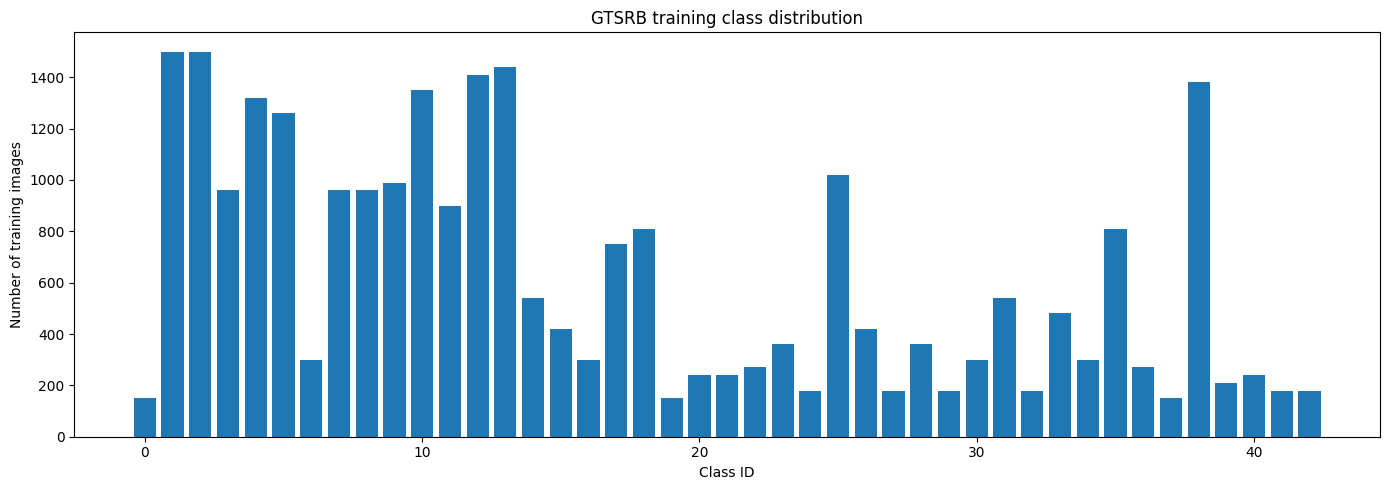

Saved: /content/traffic-sign-classification/reports/week1/class_distribution.png


In [11]:
plt.figure(figsize=(14, 5))
plt.bar(class_counts_df["ClassId"], class_counts_df["TrainCount"])
plt.xlabel("Class ID")
plt.ylabel("Number of training images")
plt.title("GTSRB training class distribution")
plt.tight_layout()

plot_path = REPORT_ROOT / "class_distribution.png"
plt.savefig(plot_path, dpi=200)
plt.show()

print("Saved:", plot_path)

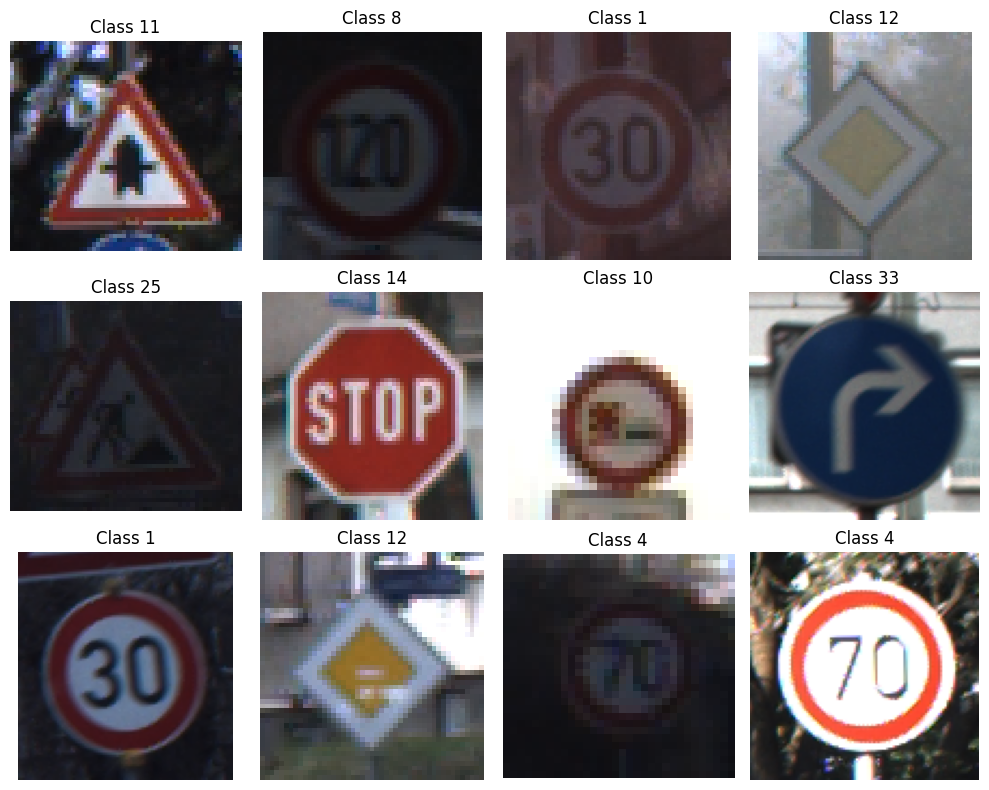

Saved: /content/traffic-sign-classification/reports/week1/sample_grid.png


In [12]:
indices = np.random.choice(len(train_raw), size=12, replace=False)

fig, axes = plt.subplots(3, 4, figsize=(10, 8))
for ax, idx in zip(axes.flatten(), indices):
    image, target = train_raw[idx]
    ax.imshow(image)
    ax.set_title(f"Class {target}")
    ax.axis("off")

plt.tight_layout()
sample_grid_path = REPORT_ROOT / "sample_grid.png"
plt.savefig(sample_grid_path, dpi=200)
plt.show()

print("Saved:", sample_grid_path)

In [13]:
sizes = []
for path in train_paths[:5000]:  # sample subset for speed in Week 1
    with Image.open(path) as im:
        sizes.append(im.size)

size_df = pd.DataFrame(sizes, columns=["width", "height"])
size_df.describe()

,width,height
count,5000.000000,5000.000000
mean,47.264000,47.857200
std,19.769301,20.003081
min,25.000000,25.000000
25%,34.000000,34.000000
50%,41.000000,42.000000
75%,54.000000,55.000000
max,164.000000,170.000000


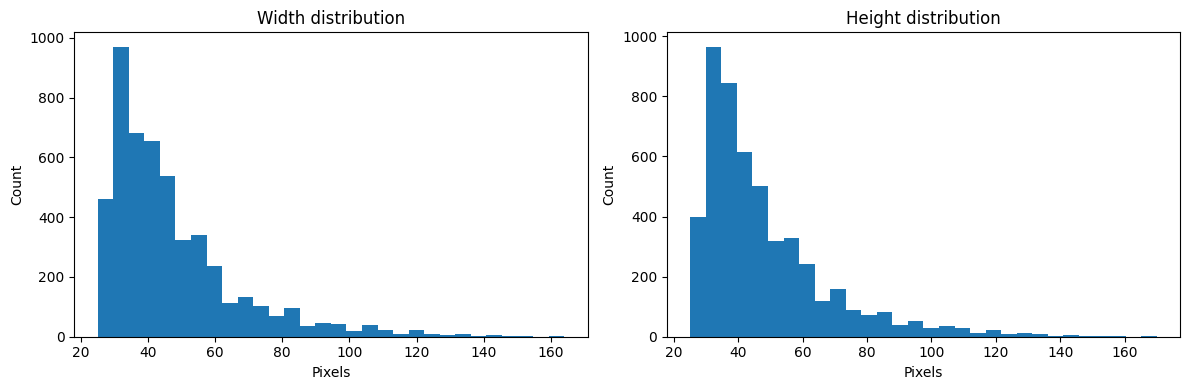

Saved: /content/traffic-sign-classification/reports/week1/image_size_histograms.png


In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(size_df["width"], bins=30)
axes[0].set_title("Width distribution")

axes[1].hist(size_df["height"], bins=30)
axes[1].set_title("Height distribution")

for ax in axes:
    ax.set_xlabel("Pixels")
    ax.set_ylabel("Count")

plt.tight_layout()
size_hist_path = REPORT_ROOT / "image_size_histograms.png"
plt.savefig(size_hist_path, dpi=200)
plt.show()

print("Saved:", size_hist_path)

In [15]:
indices = np.arange(len(train_targets))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.10,
    random_state=SEED,
    stratify=train_targets
)

split_summary = pd.DataFrame({
    "split": ["train", "val"],
    "count": [len(train_idx), len(val_idx)]
})

split_summary

,split,count
0,train,23976
1,val,2664


In [16]:
np.save(SPLIT_ROOT / "train_idx.npy", train_idx)
np.save(SPLIT_ROOT / "val_idx.npy", val_idx)
split_summary.to_csv(REPORT_ROOT / "split_summary.csv", index=False)
class_counts_df.to_csv(REPORT_ROOT / "class_counts.csv", index=False)
size_df.to_csv(REPORT_ROOT / "image_size_sample_stats.csv", index=False)

print("Saved split files and CSV reports.")

Saved split files and CSV reports.


In [17]:
IMG_SIZE = 64

basic_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

aug_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomAffine(degrees=10, translate=(0.10, 0.10), scale=(0.9, 1.1)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor()
])

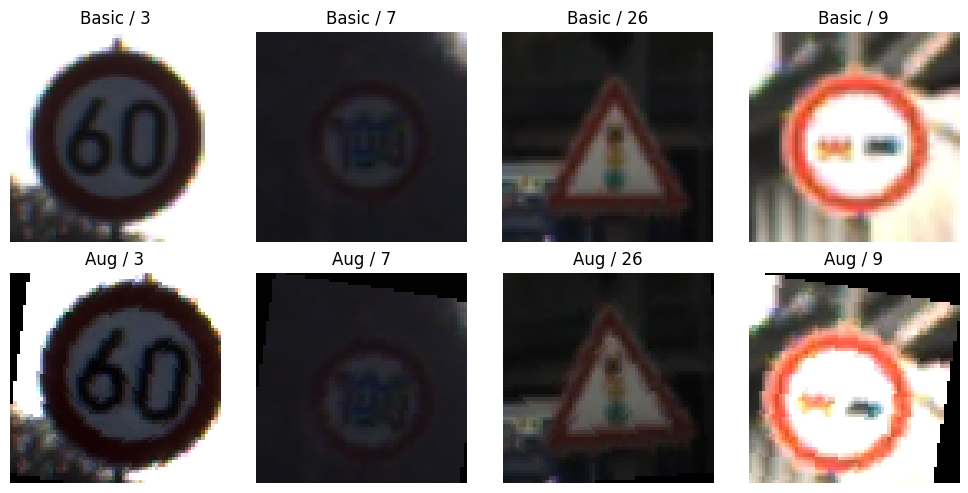

Saved: /content/traffic-sign-classification/reports/week1/transform_preview.png


In [18]:
fig, axes = plt.subplots(2, 4, figsize=(10, 5))

for col in range(4):
    image, target = train_raw[np.random.randint(len(train_raw))]

    basic_img = basic_transform(image).permute(1, 2, 0).numpy()
    aug_img = aug_transform(image).permute(1, 2, 0).numpy()

    axes[0, col].imshow(basic_img)
    axes[0, col].set_title(f"Basic / {target}")
    axes[0, col].axis("off")

    axes[1, col].imshow(np.clip(aug_img, 0, 1))
    axes[1, col].set_title(f"Aug / {target}")
    axes[1, col].axis("off")

plt.tight_layout()
tfm_path = REPORT_ROOT / "transform_preview.png"
plt.savefig(tfm_path, dpi=200)
plt.show()

print("Saved:", tfm_path)

In [19]:
summary = {
    "train_samples": len(train_raw),
    "test_samples": len(test_raw),
    "num_classes": len(set(train_targets)),
    "val_fraction": 0.10,
    "img_size_for_week2": IMG_SIZE
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(REPORT_ROOT / "week1_summary.csv", index=False)
summary_df

,train_samples,test_samples,num_classes,val_fraction,img_size_for_week2
0,26640,12630,43,0.1,64
